In [36]:
from getpass import getpass
import io
import pandas as pd
import msoffcrypto

file_path =r"C:\Users\danam\OneDrive\Desktop\Bachelorprojekt\Tidligere excel bearbejdninger\Alle Giftlinjen 2018-2022 (anonym) Aldersfordelt - Kopi.xlsx"
password = getpass("Enter Excel password: ")

decrypted = io.BytesIO()
with open(file_path, "rb") as f:
    office = msoffcrypto.OfficeFile(f)
    office.load_key(password=password)
    office.decrypt(decrypted)

# Move back to the start of the stream before reading
decrypted.seek(0)

# Specify the two sheets you want to load
sheet_names = ["Alder<70", "Alder>70"] 
# List the columns you want
keep = [
    '[Indtag tid(gift1)]',
    '[Mand(Patient data)]',
    '[Alder (år)(Patient data)]',
    '[Ingen risiko(Risiko)]',
    '[generisk navn(gift1)]',
    '[navn(gift1)]',
    '[substans type(gift1)]',
    '[Enhed(gift1)]',
    '[Styrke(gift1)]',
    '[antal(gift1)]',
    '[dosis(gift1)]',
    '[generisk navn(gift2)]',
    '[navn(gift2)]',
    '[substans type(gift2)]',
    '[Enhed(gift2)]',
    '[Styrke(gift2)]',
    '[antal(gift2)]',
    '[dosis(gift2)]',
    '[generisk navn(gift3)]',
    '[navn(gift3)]',
    '[substans type(gift3)]',
    '[Enhed(gift3)]',
    '[Styrke(gift3)]',
    '[antal(gift3)]',
    '[dosis(gift3)]',
    '[generisk navn(gift4)]',
    '[navn(gift4)]',
    '[substans type(gift4)]',
    '[Enhed(gift4)]',
    '[Styrke(gift4)]',
    '[antal(gift4)]',
    '[dosis(gift4)]',  
    '[generisk navn(gift5)]',
    '[navn(gift5)]',
    '[substans type(gift5)]',
    '[Enhed(gift5)]',
    '[Styrke(gift5)]',
    '[antal(gift5)]',
    '[dosis(gift5)]',
    '[generisk navn(gift6)]',
    '[navn(gift6)]',
    '[substans type(gift6)]',
    '[Enhed(gift6)]',
    '[Styrke(gift6)]',
    '[antal(gift6)]',
    '[Dosis(gift6)]',
    '[generisk navn(gift7)]',
    '[navn(gift7)]',
    '[substans type(gift7)]',
    '[Enhed(gift7)]',
    '[Styrke(gift7)]',
    '[antal(gift7)]',
    '[Dosis(gift7)]',
    '[generisk navn(gift8)]',
    '[navn(gift8)]',
    '[substans type(gift8)]',
    '[Enhed(gift8)]',
    '[Styrke(gift8)]',
    '[antal(gift8)]',
    '[Dosis(gift8)]',
    '[generisk navn(gift9)]',
    '[navn(gift9)]',
    '[substans type(gift9)]',
    '[Enhed(gift9)]',
    '[Styrke(gift9)]',
    '[antal(gift9)]',
    '[Dosis(gift9)]',
    '[generisk navn(gift10)]',
    '[navn(gift10)]',
    '[substans type(gift10)]',
    '[Enhed(gift10)]',
    '[Styrke(gift10)]',
    '[antal(gift10)]',
    '[Dosis(gift10)]',
    '[generisk navn(gift11)]',
    '[navn(gift11)]',
    '[substans type(gift11)]',
    '[Enhed(gift11)]',
    '[Styrke(gift11)]',
    '[antal(gift11)]',
    '[Dosis(gift11)]',
    '[generisk navn(gift12)]',
    '[navn(gift12)]',
    '[substans type(gift12)]',
    '[Enhed(gift12)]',
    '[Styrke(gift12)]',
    '[antal(gift12)]',
    '[Dosis(gift12)]',
    '[generisk navn(gift13)]',
    '[navn(gift13)]',
    '[substans type(gift13)]',
    '[Enhed(gift13)]',
    '[Styrke(gift13)]',
    '[antal(gift13)]',
    '[Dosis(gift13)]',
    '[generisk navn(gift14)]',
    '[navn(gift14)]',
    '[substans type(gift14)]',
    '[Enhed(gift14)]',
    '[Styrke(gift14)]',
    '[antal(gift14)]',
    '[Dosis(gift14)]',
    '[generisk navn(gift15)]',
    '[navn(gift15)]',
    '[substans type(gift15)]',
    '[Enhed(gift15)]',
    '[Styrke(gift15)]',
    '[antal(gift15)]',
    '[Dosis(gift15)]',
    '[Ingen(Anbefalet obs)]',
    '[Akut forgiftning(Forespørgselsart)]',
    '[Søg Hospital(hospital)]',
    '[Borger(Spørger1)]',
    '[Søg postnummer(postalcode)]',
    '[Søg By(postalcode)]',
    '[Råd(Tekst)]',
    '[Today(Oprettelse)]',
    '[Anamnese(Tekst)]',
    '[Psykiatriske sygdomme(Komorbiditet)]',
    '[Ulykke/uheld(Årsag)]',
    '[Leg(Årsag)]',
    '[Suicidal/Affekt(Årsag)]',
    '[Misbrug(Årsag)]',
    '[Forveksling(Årsag)]',
    '[Omhældning(Årsag)]',
    '[Fejldosering(Årsag)]',
    '[Levnedsmiddel(Årsag)]',
]

dfs = pd.read_excel(
    decrypted,
    sheet_name=sheet_names,
    usecols=keep
)

# All column names are now lowercase:
for sheet in sheet_names:
    dfs[sheet].columns = [c.lower() for c in dfs[sheet].columns]


young = dfs[sheet_names[0]]
old = dfs[sheet_names[1]]


In [37]:
# Controls extra output
debugOutput = False

We are building a list of equvialents for the medicine, so that eg. panodil and paracetamol are not counted twice as two seperate medicines in one row.
See the work in new ipynb notebook "list of equivalent names for medicines.ipynb.ipynb"

In [38]:
# Loading list of equivalent medicine names from generated json file
import json
with open('equivalent_names.json', encoding='utf-8') as f:
    groups = json.load(f)

1.  The file with every recognised drug name is loaded into the (lower-case) set `medicines`; the synonym groups JSON goes into `groups`. Two DataFrames, `young` and `old`, are assumed to be in memory already.

2.  Lists of the 15 generic-name columns, the 15 brand-name columns, and the two free-text columns are built.  The first two lists are joined into `name_cols` (30 structured columns); all three lists together are lower-cased and concatenated into `all_cols`, the master list of columns to scan when we really need every possible word.

3.  `split_words` is a tiny tokenizer: commas, semicolons and slashes become spaces, the text is lower-cased, then split on white-space.

4.  `build_word_frequencies` walks through the requested columns in both DataFrames, tokenises every non-null cell, and counts how often each token occurs; the union for the two sheets is stored in `raw_freq`.

5.  For every synonym group the spelling with the highest raw frequency (ties broken by the longest string) is chosen as the canonical form; every variant is mapped to that canonical form in `synonym_to_canonical`.

6.  `medicine_counter` iterates row by row, gathers every token that is a recognised medicine from **all_cols**, converts each to its canonical name, counts each canonical name once per row and finally returns a Counter.

7.  `row_has_medicine` now looks **only at the 30 structured columns** contained in `name_cols`; it ignores the two free-text columns.  It returns True as soon as a medicine name (whole entry or token) is found.

8.  `filter_and_report` keeps rows where `row_has_medicine` is True, discards the rest, prints the row counts, shows up to 100 discarded rows that had long entries for manual inspection, and displays the 50 most frequent canonical medicines among the kept rows (via `medicine_counter`).  It returns the kept and deleted DataFrames.

9.  The function in step 8 is executed for both `young` and `old`, producing `young_filtered`, `young_deleted`, `old_filtered`, `old_deleted`, together with the on-screen summaries.

In [39]:
# ---------------------------------------------------------------------------
# 0.  Imports / general set-up
# ---------------------------------------------------------------------------
import json
import pandas as pd
from collections import Counter
from IPython.display import display

pd.set_option('display.max_rows',    None)
pd.set_option('display.max_columns', None)

# ---------------------------------------------------------------------------
# 1.  Load input data that you already have
# ---------------------------------------------------------------------------
with open('unique_medicine_names.txt', encoding='utf-8') as f:
    medicines = set(line.strip().lower() for line in f if line.strip())

with open('equivalent_names.json', encoding='utf-8') as f:
    groups = json.load(f)                 # list[list[str]]

# young  and old dataframes are assumed to be in memory already
# (their column names must already have been forced to lower-case)
# ---------------------------------------------------------------------------
# 2.  Column lists
# ---------------------------------------------------------------------------
generisk_cols = [f'[generisk navn(gift{i})]' for i in range(1, 16)]
navn_cols     = [f'[navn(gift{i})]'           for i in range(1, 16)]
extra_cols    = ['[råd(tekst)]', '[anamnese(tekst)]']

name_cols = [*generisk_cols, *navn_cols]          # 30 structured columns
name_cols = [c.lower() for c in name_cols]

all_cols = [*name_cols, *[c.lower() for c in extra_cols]]

# ---------------------------------------------------------------------------
# 3.  Helper – tokenizer
# ---------------------------------------------------------------------------
def split_words(text: str):
    """Return a list of lowercase 'words' cut on space, ',', ';', '/'."""
    return (
        text.replace(',', ' ')
            .replace(';', ' ')
            .replace('/', ' ')
            .lower()
            .split()
    )

# ---------------------------------------------------------------------------
# 4.  PRE-SCAN – build raw frequencies for every word in every sheet
# ---------------------------------------------------------------------------
def build_word_frequencies(dfs, columns) -> Counter:
    freq = Counter()
    for df in dfs:
        for col in columns:
            if col not in df.columns:
                continue
            for entry in df[col].dropna().astype(str).values:
                for word in split_words(entry):
                    freq[word] += 1
    return freq

raw_freq = build_word_frequencies([young, old], all_cols)

# ---------------------------------------------------------------------------
# 5.  Decide canonical synonym per group
# ---------------------------------------------------------------------------
synonym_to_canonical = {}

for group in groups:
    group = [g.lower() for g in group]
    best_freq = max(raw_freq.get(g, 0) for g in group)
    candidates = [g for g in group if raw_freq.get(g, 0) == best_freq]
    canonical  = max(candidates, key=len)          # tie-break by length
    for g in group:
        synonym_to_canonical[g] = canonical

# ---------------------------------------------------------------------------
# 6.  Medicine counter (row-deduplicated, canonicalised)
# ---------------------------------------------------------------------------
def medicine_counter(df: pd.DataFrame) -> Counter:
    counter = Counter()
    for _, row in df[all_cols].iterrows():
        seen_this_row = set()
        for col in all_cols:
            if pd.isnull(row[col]):
                continue
            for word in split_words(str(row[col])):
                if word in medicines:
                    word = synonym_to_canonical.get(word, word)
                    seen_this_row.add(word)
        counter.update(seen_this_row)
    return counter

# ---------------------------------------------------------------------------
# 7.  Has-medicine test – Fixed for multi-word medicines
# ---------------------------------------------------------------------------
# Create a small set of just the multi-word medicines for fast scanning
multi_word_medicines = {m for m in medicines if ' ' in m}

def row_has_medicine(row) -> bool:
    for col in name_cols:
        value = row.get(col)
        if pd.isnull(value):
            continue
            
        entry = str(value).strip().lower()
        
        # 1. Check if the entire cell is an exact match
        if entry in medicines:
            return True
            
        # 2. Check tokenized single words
        words = split_words(entry)
        if any(word in medicines for word in words):
            return True
            
        # 3. Check if any multi-word medicine is hiding inside a longer sentence
        if any(multi_med in entry for multi_med in multi_word_medicines):
            return True
            
    return False

# ---------------------------------------------------------------------------
# 8.  Filter, report and show diagnostics
# ---------------------------------------------------------------------------
def filter_and_report(df, label):
    total_start = len(df)
    mask = df.apply(row_has_medicine, axis=1)

    deleted = df[~mask].copy()
    kept    = df[mask].copy()

    print(f"\nSheet: {label}")
    print(f"  Rows at start:  {total_start}")
    print(f"  Rows deleted:   {len(deleted)}")
    print(f"  Rows remaining: {len(kept)}")

    # --- show up to 100 suspect deleted rows -------------------------------
    def has_long_entry(r):
        return any(
            pd.notnull(r[col]) and len(str(r[col])) > 20
            for col in name_cols
        )

    candidates = deleted[deleted.apply(has_long_entry, axis=1)]
    sample = (
        candidates.sample(n=min(100, len(candidates)), random_state=42)
        if not candidates.empty else candidates
    )

    #print("  Up to 100 random deleted rows with >20 chars in any name/generic column:")
    #display(sample)

    # --- Top-50 canonical medicine list ------------------------------------
    #print(f"\nTop 50 medicine matches in '{label}' (canonical names):")
    #top_50 = medicine_counter(kept).most_common(50)
    #display(pd.DataFrame(top_50, columns=['medicine', 'count']))

    return kept, deleted

# ---------------------------------------------------------------------------
# 9.  Run on both sheets
# ---------------------------------------------------------------------------
young_filtered, young_deleted = filter_and_report(young, "young")
old_filtered,   old_deleted   = filter_and_report(old,   "old")


Sheet: young
  Rows at start:  154529
  Rows deleted:   100493
  Rows remaining: 54036

Sheet: old
  Rows at start:  8620
  Rows deleted:   3009
  Rows remaining: 5611


In [40]:
# Deleting "young" and "old" so we don't accidentally use them
del young, old

Next we convert all [substans type gift#] that are ZZMED to MED.

In [41]:
# ------------------------------------------------------------------
# Update *existing* dataframes `young_filtered` and `old_filtered`
# ------------------------------------------------------------------

# columns to inspect/modify
subst_cols = [f'[substans type(gift{i})]' for i in range(1, 16)]

def convert_zzmed(df):
    """
    In-place replacement of every 'ZZMED' (any case) with 'MED'
    in the 15 “[substans type(gift#)]” columns.
    Returns the number of cells changed.
    """
    # keep only columns that exist in this dataframe
    cols = [c for c in subst_cols if c in df.columns]

    total = 0
    for c in cols:
        # build a boolean mask for the column
        mask = df[c].astype(str).str.upper().eq('ZZMED')
        total += mask.sum()
        # replace in place
        df.loc[mask, c] = 'MED'

    return int(total)

# --- run conversion -------------------------------------------------------
young_changes = convert_zzmed(young_filtered)
old_changes   = convert_zzmed(old_filtered)

print(f'ZZMED➜MED conversions – young: {young_changes}')
print(f'ZZMED➜MED conversions – old  : {old_changes}')
print(f'Total conversions           : {young_changes + old_changes}')

ZZMED➜MED conversions – young: 28531
ZZMED➜MED conversions – old  : 3629
Total conversions           : 32160


We now have data that represents rows, where there is a medicine mentioned. 
It must therefore be assumed, that the rest of the rows are not related to medical poisoning. 
These rows are therefore deleted, and the new dataset can be reviewed to evaluate the next step in cleaning the data.
We have the relevant data in `young_filtered` and `old_filtered`

Our next step is to combine duplicate cases, so that we don't count 1 poisoning case more than 1 time.


In [42]:
# Looking at the filtered data to see our next step.
# ---------------------------------------------------------------------------
# Show up to 100 random rows from each filtered sheet
# ---------------------------------------------------------------------------
from IPython.display import display

def show_random_rows(df, label, n=100, seed=42):
    """Display up to *n* random rows of *df* (or all if df is smaller)."""
    if df.empty:
        print(f"{label} is empty – nothing to show.\n")
        return
    
    sample = df.sample(n=min(n, len(df)), random_state=seed)
    print(f"\nRandom {len(sample)} rows from '{label}':")
    display(sample)

#show_random_rows(young_filtered, "young_filtered")
#show_random_rows(old_filtered,  "old_filtered")

## Duplicate-detection rule used by `find_duplicates`  
*(clique-based implementation – 2024-06, “multi-poison” revision)*  
---

### 1 Hard-key compatibility  
Two rows can **only** belong to the same potential case if they satisfy **all**
of the conditions below.

| Condition | Columns involved | Requirement |
|-----------|-----------------|-------------|
| Demographics | `[søg postnummer(postalcode)]`   `[mand(patient data)]`   `[alder (år)(patient data)]` | must be **identical** |
| Poison names – 30 raw columns | `[generisk navn(gift1)] … [generisk navn(gift15)]`<br>`[navn(gift1)] … [navn(gift15)]` | see “Poison-set rule” |

Poison-set rule  
1. For every row build  
   `POISON_SET(row)  = { all non-missing strings found in the 30 poison columns }`.  
   (Within one row duplicates and order are ignored.)  
2. Let A and B be two rows with poison sets `S_A` and `S_B`.  
   A and B pass the hard-key test iff  

     `S_A ⊆ S_B`  or  `S_B ⊆ S_A`  

   — i.e. the *smaller* set must be a subset of the larger; neither row may
   contain a poison name that the other row explicitly does **not** list.

Only rows that fulfil both the demographic equality and the poison-set
subset rule enter the subsequent stages.

---

### 2 Temporal proximity  
Inside every hard-key compatible group the rows are sorted by enquiry date  
`[today(oprettelse)]`.  
Whenever the absolute gap between two consecutive rows exceeds **4 days**
(`MAX_GAP = 4`) a new **time segment** starts.  
All later duplicate checks are performed **independently** inside each
segment.

---

### 3 Clique-based cluster formation inside one time segment  
Within one segment we build **duplicate clusters** so that *every pair of
rows* inside the cluster is mutually compatible.

1. **Candidate ordering**  
   Rows are processed in descending order of the count of non-missing values in
   the eight **Årsag** (“cause”) columns  
   `[ulykke/uheld(årsag)]`, …, `[levnedsmiddel(årsag)]`.

2. **Attempt to join an existing cluster**  
   For every existing cluster, the candidate row is compared to **all rows
   already present**.  It can join the first cluster where it is compatible
   with everybody (rules 3 a–3 c).  If no such cluster exists, a **new**
   cluster is started with that single row.

3. **Post-processing**  
   After all rows have been examined, clusters that contain fewer than two rows
   are discarded.

Because a candidate must match **every** member of a cluster, the resulting
clusters are cliques: no transitive “bridging” via partially filled columns is
possible.

#### 3 a Poison-set compatibility (new)  
Let `U_cluster` be the union of `POISON_SET` for all rows already in the
cluster.  
The candidate row C with set `S_C` is acceptable *iff* `S_C ⊆ U_cluster`
(C may omit substances but may not add new ones).

#### 3 b Semi-hard-key columns (unchanged)  
Four columns must agree pair-wise inside a cluster (symmetric rule, NaN acts
as a wildcard):

| Semi-hard-key column              |
|-----------------------------------|
| `[styrke(gift1)]`                 |
| `[antal(gift1)]`                  |
| `[dosis(gift1)]`                  |
| `[søg hospital(hospital)]`        |

Mismatch ⇔ both rows hold non-missing values **and** the values differ.

#### 3 c Årsag (“cause”) columns (unchanged)  
Eight cause columns use the existing *asymmetric* comparison rule  
(NaN in the reference row forbids the candidate from supplying a value that
disagrees).

---

### 4 Result returned by `find_duplicates`  
Rows that belong to any duplicate cluster are returned with two additional
columns:

| Column         | Type | Meaning                                   |
|----------------|------|-------------------------------------------|
| `is_duplicate` | bool | always `True` for these rows              |
| `dup_case_id`  | int  | Consecutive identifier of the cluster     |

Rows that are not part of any cluster are omitted from the returned
DataFrame.

In [43]:
# ================================================================
#  Duplicate detection – *clique-based* cluster logic
#              multi-poison (“subset”) revision 2024-06
# ================================================================
def find_duplicates(df):
    """
    Duplicate detection using the specification
        “Duplicate-detection rule … (multi-poison revision)”.

    Main differences to the previous version
    ----------------------------------------
    1.  30 poison-name columns are treated as ONE *unordered* set.
        For every row we build
            POISON_SET(row) = { all non-missing strings in those 30 cols }.

        Two rows are poison-compatible  ⇔
            POISON_SET(A) ⊆ POISON_SET(B)  or  POISON_SET(B) ⊆ POISON_SET(A)
        (⇒ the smaller set is a subset of the larger).

    2.  The demographic fields alone form the primary grouping key
            [søg postnummer(postalcode)],
            [mand(patient data)],
            [alder (år)(patient data)]
        – the poison subset rule is enforced later while the clusters
        are built.

    All other steps (temporal segmentation, semi-hard columns, cause
    columns, result formatting) are unchanged.

    The function returns **only** the rows that belong to a duplicate
    cluster and appends the columns

        is_duplicate : bool   (always True)
        dup_case_id  : int    (consecutive identifier)

    A short size report is printed at the end.
    """
    # ----------------------------------------------------------------
    # imports (local keeps namespace clean for caller)
    # ----------------------------------------------------------------
    import numpy as np
    import pandas as pd

    # ----------------------------------------------------------------
    # configuration
    # ----------------------------------------------------------------
    DATE_COL   = '[today(oprettelse)]'

    # ---- grouping (demographic) hard key ---------------------------
    KEY_COLS   = [
        '[søg postnummer(postalcode)]',
        '[mand(patient data)]',
        '[alder (år)(patient data)]',
    ]

    # ---- poison columns (30) ---------------------------------------
    POISON_GENERIC = [f'[generisk navn(gift{i})]' for i in range(1, 16)]
    POISON_BRAND   = [f'[navn(gift{i})]'           for i in range(1, 16)]
    POISON_COLS    = POISON_GENERIC + POISON_BRAND       # length 30

    # ---- semi-hard columns (unchanged) -----------------------------
    SEMI_COLS  = [
        '[styrke(gift1)]',
        '[antal(gift1)]',
        '[dosis(gift1)]',
        '[søg hospital(hospital)]',
    ]

    # ---- cause columns (unchanged) ---------------------------------
    CAUSE_COLS = [
        '[ulykke/uheld(årsag)]',
        '[leg(årsag)]',
        '[suicidal/affekt(årsag)]',
        '[misbrug(årsag)]',
        '[forveksling(årsag)]',
        '[omhældning(årsag)]',
        '[fejldosering(årsag)]',
        '[levnedsmiddel(årsag)]',
    ]

    MAX_GAP = 4          # maximum days between consecutive rows

    # ----------------------------------------------------------------
    # helper: Tokenize, canonicalize, and extract ONLY valid medicines
    # ----------------------------------------------------------------
    def _row_to_poison_set(row_vals):
        out = set()
        for v in row_vals:
            if pd.notna(v) and str(v).strip() != '':
                # Tokenize exactly like we did in medicine_counter
                for word in split_words(str(v)):
                    if word in medicines:
                        canonical = synonym_to_canonical.get(word, word)
                        out.add(canonical)
        return frozenset(out)

    # ----------------------------------------------------------------
    # helper – build clusters inside ONE time-segment (Fixed Union Logic)
    # ----------------------------------------------------------------
    def _clusters_in_segment(seg: pd.DataFrame):
        n = len(seg)
        if n < 2:
            return []

        cause_dat = seg[CAUSE_COLS].to_numpy(copy=False)
        cause_nn  = ~pd.isna(cause_dat)
        semi_dat  = seg[SEMI_COLS].to_numpy(copy=False)
        semi_nn   = ~pd.isna(semi_dat)
        p_sets    = seg['__poison_set'].tolist()

        order = np.argsort(-cause_nn.sum(axis=1))
        clusters = []

        for pos in order:
            placed = False
            for cl in clusters:
                c_idx = np.asarray(cl)

                # --------- CAUSE mismatches --------------------------
                cand_cause_nn   = cause_nn[pos]
                cand_cause_vals = cause_dat[pos]
                ref_cause_nn    = cause_nn[c_idx]
                ref_cause_vals  = cause_dat[c_idx]

                cond1 = cand_cause_nn & (~ref_cause_nn)
                cond2 = cand_cause_nn & ref_cause_nn & (cand_cause_vals != ref_cause_vals)
                mism_cause = (cond1 | cond2).any()

                # --------- SEMI-hard mismatches ----------------------
                cand_semi_nn   = semi_nn[pos]
                cand_semi_vals = semi_dat[pos]
                ref_semi_nn    = semi_nn[c_idx]
                ref_semi_vals  = semi_dat[c_idx]

                mism_semi = (cand_semi_nn & ref_semi_nn & \
                             (cand_semi_vals != ref_semi_vals)).any()

                # --------- POISON-set mismatches (FIXED UNION RULE) --
                set_c = p_sets[pos]
                
                # Build the union of all poison sets currently in the cluster
                u_cluster = frozenset().union(*(p_sets[idx] for idx in c_idx))
                
                # Candidate must be a subset of the cluster union
                mism_poison = not (set_c <= u_cluster)

                # --------- final decision ---------------------------
                if not (mism_cause or mism_semi or mism_poison):
                    cl.append(pos)
                    placed = True
                    break

            if not placed:
                clusters.append([pos])

        return [seg.iloc[cl].copy() for cl in clusters if len(cl) >= 2]
    
    # ----------------------------------------------------------------
    # main routine
    # ----------------------------------------------------------------
    df = df.copy()

    # -- create POISON_SET for every row ------------------------------
    df['__poison_set'] = df[POISON_COLS].apply(_row_to_poison_set, axis=1)

    # -- make sure the DATE column is proper datetime -----------------
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

    # -- containers for the result markers ----------------------------
    is_dup      = pd.Series(False, index=df.index, dtype=bool)
    dup_case_id = pd.Series(np.nan,  index=df.index, dtype='float')

    # -- iterate over demographic groups ------------------------------
    cid = 0
    for _, grp in df.groupby(KEY_COLS, sort=False, observed=True):
        grp = grp.sort_values(DATE_COL)

        # ---- split by time gap --------------------------------------
        gap          = grp[DATE_COL].diff().dt.days.abs().fillna(MAX_GAP + 1)
        grp['__seg'] = (gap > MAX_GAP).cumsum()

        for _, seg in grp.groupby('__seg', sort=False):
            seg = seg.drop(columns='__seg')
            for cl in _clusters_in_segment(seg):
                idx = cl.index
                is_dup.loc[idx]      = True
                dup_case_id.loc[idx] = cid
                cid += 1

    # ----------------------------------------------------------------
    # assemble final dataframe
    # ----------------------------------------------------------------
    result = df[is_dup].copy()
    if not result.empty:
        result['is_duplicate'] = True
        result['dup_case_id']  = dup_case_id[is_dup].astype('int64')
        # internal helper column not wanted in the output
        result = result.drop(columns='__poison_set')
    else:
        result = pd.DataFrame(
            columns=df.columns.tolist() + ['is_duplicate', 'dup_case_id']
        )

    # ----------------------------------------------------------------
    # short size report
    # ----------------------------------------------------------------
    if result.empty:
        print("No duplicate cases detected.")
    else:
        sz   = result.groupby('dup_case_id').size()      # rows per case
        dist = sz.value_counts().sort_index()

        print("\nDuplicate case size distribution:")
        for rows, n_cases in dist.items():
            print(f"  {rows} rows : {n_cases} case(s)")
        print(f"  total     : {len(sz)} cases\n")

    return result

# --------------------------------------------------------------------
# Example usage
# --------------------------------------------------------------------
old_dups   = find_duplicates(old_filtered)
young_dups = find_duplicates(young_filtered)


Duplicate case size distribution:
  2 rows : 417 case(s)
  3 rows : 56 case(s)
  4 rows : 4 case(s)
  5 rows : 1 case(s)
  7 rows : 1 case(s)
  total     : 479 cases


Duplicate case size distribution:
  2 rows : 4919 case(s)
  3 rows : 751 case(s)
  4 rows : 142 case(s)
  5 rows : 29 case(s)
  6 rows : 6 case(s)
  7 rows : 1 case(s)
  9 rows : 1 case(s)
  total     : 5849 cases



In [44]:
print("Young sheet – duplicate cases:", young_dups['dup_case_id'].nunique())
print("Old   sheet – duplicate cases:", old_dups['dup_case_id'].nunique())


Young sheet – duplicate cases: 5849
Old   sheet – duplicate cases: 479


In [45]:
from IPython.display import display, HTML
import pandas as pd

def display_duplicate_cases(df: pd.DataFrame,
                            sheet_label: str,
                            n_cases: int = 20) -> None:
    """
    Show every column of every row that belongs to the first *n_cases*
    duplicate cases found in *df* (use n_cases=None to show them all).

    Parameters
    ----------
    df          The dataframe returned by `find_duplicates`
    sheet_label A title that will be shown above each block
    n_cases     Number of duplicate cases to display (None = all)
    """

    DATE_COL = '[today(oprettelse)]'
    
    if df.empty:
        display(HTML(f"<h3>{sheet_label}: no duplicate cases</h3>"))
        return

    # make sure nothing is truncated in the HTML rendering
    with pd.option_context("display.max_columns", None,
                           "display.max_colwidth", None,
                           "display.width", None):
        case_ids = df["dup_case_id"].drop_duplicates()
        if n_cases is not None:
            case_ids = case_ids.head(n_cases)

        for cid in case_ids:
            subset = (
                df[df["dup_case_id"] == cid]
                .sort_values(DATE_COL)          # chronological inside the case
            )
            display(HTML(
                f"<h4>{sheet_label} – duplicate case {cid} "
                f"({len(subset)} rows)</h4>"
            ))
            display(subset)

# How many cases were detected?
print("Young sheet – duplicate cases:", young_dups["dup_case_id"].nunique())
print("Old   sheet – duplicate cases:", old_dups["dup_case_id"].nunique())

# Show the first 20 duplicate cases from each sheet
#display_duplicate_cases(young_dups, "YOUNG SHEET", n_cases=20)
#display_duplicate_cases(old_dups,   "OLD SHEET",   n_cases=20)

Young sheet – duplicate cases: 5849
Old   sheet – duplicate cases: 479


Merging the duplicate cases:
- Collapses every duplicate cluster (same dup_case_id) into a single row  
- Concatenates all textual information, but for any non-string column simply keeps the first non-blank value that occurs in the cluster  
- Removes the original duplicate rows from young_filtered / old_filtered and appends the merged rows instead (so the variables young_filtered and old_filtered now contain one row per case)  
- Shows the first 20 merged cases from each sheet

In [46]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# column name used for chronological ordering inside a cluster
# (needed only if you want the “first non-blank value” to come
#  from the earliest row)
# ------------------------------------------------------------
DATE_COL = '[today(oprettelse)]'


import datetime

def _merge_one_cluster(grp: pd.DataFrame,
                       prototype: pd.DataFrame) -> dict:
    """
    Collapse *grp* (all rows of one dup_case_id) into one dict
    that later becomes a single dataframe row.
    """
    if DATE_COL in grp.columns:
        grp = grp.sort_values(DATE_COL)

    row = {}
    for col in prototype.columns:
        ser = grp[col].dropna()

        if ser.empty:
            row[col] = np.nan
            continue

        # Check if the column is explicitly a datetime type
        is_datetime = pd.api.types.is_datetime64_any_dtype(prototype[col])
        
        # If it's an object/string, we need to double check it isn't hiding datetime objects
        if not is_datetime and (prototype[col].dtype == object or pd.api.types.is_string_dtype(prototype[col].dtype)):
            first_valid = ser.iloc[0]
            
            # Safety check: Is this "object" actually a date?
            if isinstance(first_valid, (pd.Timestamp, datetime.datetime, datetime.date)):
                row[col] = first_valid
            else:
                # Safe to string-join
                vals = [str(v) for v in ser.unique() if str(v).strip() != ""]
                row[col] = " | ".join(vals) if vals else np.nan
        else:
            # numeric / bool / datetime  → first non-blank value
            row[col] = ser.iloc[0]

    row["dup_case_id"]  = grp["dup_case_id"].iloc[0]
    row["is_duplicate"] = True
    return row


def merge_duplicate_cases(df: pd.DataFrame, dup_df: pd.DataFrame) -> pd.DataFrame:
    """
    Return *df* where every cluster of duplicate rows found in *dup_df*
    has been replaced by one merged row.
    """
    if dup_df.empty:
        return df

    # build one merged row per duplicate case ----------------------------
    merged_rows = [
        _merge_one_cluster(grp, df)
        for _, grp in dup_df.groupby("dup_case_id", sort=False)
    ]
    merged_df = pd.DataFrame(merged_rows, columns=df.columns.tolist()
                                               + ["dup_case_id", "is_duplicate"])

    # remove all original duplicate rows and append the merged ones -------
    df_no_dups = df.drop(index=dup_df.index)
    result = pd.concat([df_no_dups, merged_df], ignore_index=True)

    return result


# -----------------------------------------------------------------------
# apply to both age groups
# -----------------------------------------------------------------------
young_filtered = merge_duplicate_cases(young_filtered, young_dups)
old_filtered   = merge_duplicate_cases(old_filtered,   old_dups)



In [47]:
print(f"Rows in Young after merge: {len(young_filtered)}")
print(f"Rows in Old after merge: {len(old_filtered)}")

Rows in Young after merge: 47029
Rows in Old after merge: 5060


In [48]:
# -----------------------------------------------------------------------
# show the first 20 merged cases from each sheet
# -----------------------------------------------------------------------
def show_merged_cases(df: pd.DataFrame, label: str, n: int = 20):
    mask = df.get("is_duplicate", False)

    # make sure the mask is a proper Boolean Series
    if not isinstance(mask, pd.Series):
        mask = pd.Series(mask, index=df.index)
    mask = mask.fillna(False).astype(bool)

    subset = df[mask].head(n)          # only merged rows
    if subset.empty:
        display(HTML(f"<h3>{label}: no merged cases</h3>"))
    else:
        display(HTML(f"<h3>{label} – first {len(subset)} merged cases</h3>"))
        with pd.option_context("display.max_columns", None,
                               "display.max_colwidth", None,
                               "display.width", None):
            display(subset)


#show_merged_cases(young_filtered, "YOUNG SHEET", n=20)
#show_merged_cases(old_filtered,   "OLD SHEET",   n=20)

Two auxiliary columns are now present in young_filtered and old_filtered:

- is_duplicate – Boolean flag  
  ‑ TRUE for every row that originates from a duplicate cluster (the single merged row that now represents the cluster).  
  ‑ FALSE / NaN for rows that never belonged to a duplicate cluster.

- dup_case_id – Integer identifier  
  ‑ Each duplicate cluster receives a consecutive number (0, 1, 2, …).  
  ‑ Rows that are not part of any duplicate cluster hold NaN in this column.

Together these fields let you
  – recognise which rows were produced by the merging routine, and  
  – see which merged rows belong to the same original case (because they share the same dup_case_id).

After the merge step every former cluster has been collapsed into exactly one row, and that row retains the cluster’s identifier.  
Therefore:

- For each non-null value in dup_case_id there is exactly one row in the dataframe.  
- All other rows (those that never belonged to a duplicate cluster) have dup_case_id = NaN.

So within each sheet the non-null dup_case_id values are unique.


Looking at “[Akut forgiftning(Forespørgselsart)]” next, to see if we can further eliminate non-poisoning related cases.

In [49]:
# ---------------------------------------------------------------------------
# Unique values + counts for the column
# “[Akut forgiftning(Forespørgselsart)]”
# ---------------------------------------------------------------------------
from IPython.display import display

COLUMN = '[Akut forgiftning(Forespørgselsart)]'   # original spelling

def value_counts_report(df, label, column=COLUMN, dropna=False):
    """
    Show a table of unique values and their counts for *column* in *df*.
    If *dropna* is False, missing values are counted under the label '(NaN)'.
    """
    # --- find the exact column name (case-insensitive) ----------------------
    col_map   = {c.lower(): c for c in df.columns}
    real_col  = col_map.get(column.lower())
    if real_col is None:
        print(f"{label}: column '{column}' not found.")
        return
    
    # --- build the value-counts table ---------------------------------------
    series = df[real_col]
    if not dropna:
        series = series.fillna('(NaN)')
    counts = (series.value_counts(dropna=dropna)
                    .reset_index()
                    .rename(columns={'index': 'value', real_col: 'count'}))
    if debugOutput: 
        print(f"\nUnique values for '{real_col}' in {label}:")
        display(counts)

# Reports for each filtered DataFrame
value_counts_report(young_filtered, 'young_filtered')
value_counts_report(old_filtered,  'old_filtered')

# Optional: combined view of both sheets
combined_filtered = pd.concat([young_filtered, old_filtered], ignore_index=True)
value_counts_report(combined_filtered, 'combined_filtered')

In [50]:
# ---------------------------------------------------------------------------
# Show 100 random rows (or all if <100) for which
# '[Akut forgiftning(Forespørgselsart)]' == 'Teoretisk forespørgsel'
# – but only the columns we care about, and with unlimited column width
# ---------------------------------------------------------------------------
import pandas as pd
from IPython.display import display

TARGET_COL   = '[Akut forgiftning(Forespørgselsart)]'
TARGET_VALUE = 'Teoretisk forespørgsel'

# columns you want to inspect (original spellings)
wanted_cols = [
    '[Råd(Tekst)]', '[Today(Oprettelse)]', '[Anamnese(Tekst)]',
    '[Indtag tid(gift1)]', '[Mand(Patient data)]',
    '[Alder (år)(Patient data)]', '[Ingen risiko(Risiko)]',
    '[generisk navn(gift1)]', '[navn(gift1)]', '[substans type(gift1)]',
    '[Enhed(gift1)]', '[Styrke(gift1)]', '[antal(gift1)]', '[dosis(gift1)]'
]

# make sure we can see the full cell content
pd.set_option('display.max_colwidth', None)

def show_random_subset(df, label, n=100, seed=42):
    # map to real column names irrespective of case -------------------------
    col_map = {c.lower(): c for c in df.columns}
    real_target = col_map.get(TARGET_COL.lower())
    if real_target is None:
        print(f"{label}: column '{TARGET_COL}' not found.")
        return

    # filter the rows --------------------------------------------------------
    mask   = df[real_target].astype(str).str.lower() == TARGET_VALUE.lower()
    subset = df[mask]

    if subset.empty:
        print(f"{label}: no rows match the condition.")
        return

    sample = subset.sample(n=min(n, len(subset)), random_state=seed)

    # pick wanted columns that are present ----------------------------------
    real_wanted = [col_map[c.lower()] for c in wanted_cols if c.lower() in col_map]

    print(f"\n{label}: {len(subset)} rows match; showing {len(sample)}.")
    display(sample[real_wanted])

# run for both filtered DataFrames ------------------------------------------
#show_random_subset(young_filtered, "young_filtered")
#show_random_subset(old_filtered,  "old_filtered")

In [51]:
# ---------------------------------------------------------------------------
# Remove in-place the rows where
#   “[Akut forgiftning(Forespørgselsart)]” == “Teoretisk forespørgsel”  AND
#   “[Ingen risiko(Risiko)]”  is NaN  OR  equals “Ingen risiko”
# ---------------------------------------------------------------------------
def remove_theoretical_no_risk(df, label,
                               col_query='[Akut forgiftning(Forespørgselsart)]',
                               col_risk='[Ingen risiko(Risiko)]'):
    # --- locate the exact column names (case-insensitive) -------------------
    cmap      = {c.lower(): c for c in df.columns}
    q_col     = cmap.get(col_query.lower())
    risk_col  = cmap.get(col_risk.lower())

    if q_col is None or risk_col is None:
        raise KeyError("Required column(s) not found in DataFrame")

    # --- build mask of rows to drop ----------------------------------------
    to_drop = (
        df[q_col].astype(str).str.lower().eq('teoretisk forespørgsel') &
        (
            df[risk_col].isna() |
            df[risk_col].astype(str).str.strip().str.lower().eq('ingen risiko')
        )
    )

    # --- report and drop in-place ------------------------------------------
    before = len(df)
    df.drop(index=df[to_drop].index, inplace=True)
    after  = len(df)

    print(f"{label}: dropped {before-after} rows  (from {before} → {after})")

# Apply directly to the existing DataFrames
remove_theoretical_no_risk(young_filtered, "young_filtered")
remove_theoretical_no_risk(old_filtered,  "old_filtered")

young_filtered: dropped 1274 rows  (from 47029 → 45755)
old_filtered: dropped 171 rows  (from 5060 → 4889)


In [52]:
# ---------------------------------------------------------------------------
# Show up to 100 random rows where
# “[Akut forgiftning(Forespørgselsart)]” is missing (NaN)
# – one sample for young_filtered and one for old_filtered
# ---------------------------------------------------------------------------
import pandas as pd
from IPython.display import display

pd.set_option('display.max_colwidth', None)      # show full cell text

TARGET_COL = '[Akut forgiftning(Forespørgselsart)]'

# the same “interesting” columns as before
wanted_cols = [
    'is_duplicate','[Råd(Tekst)]', '[Today(Oprettelse)]', '[Anamnese(Tekst)]',
    '[Indtag tid(gift1)]', '[Mand(Patient data)]',
    '[Alder (år)(Patient data)]', '[Ingen risiko(Risiko)]',
    '[generisk navn(gift1)]', '[navn(gift1)]', '[substans type(gift1)]',
    '[Enhed(gift1)]', '[Styrke(gift1)]', '[antal(gift1)]', '[dosis(gift1)]'
]

def show_random_nan_rows(df, label, n=100, seed=42, col=TARGET_COL):
    # exact column name (case-insensitive)
    cmap  = {c.lower(): c for c in df.columns}
    real  = cmap.get(col.lower())
    if real is None:
        print(f"{label}: column '{col}' not found.")
        return
    
    # rows where the column is truly NaN  (not a string)
    subset = df[pd.isna(df[real])]
    
    if subset.empty:
        print(f"{label}: no NaN rows found for '{real}'.")
        return
    
    sample = subset.sample(n=min(n, len(subset)), random_state=seed)
    
    # keep only the wanted columns that actually exist in the DF
    available_cols = [cmap[c.lower()] for c in wanted_cols if c.lower() in cmap]
    
    print(f"\n{label}: {len(subset)} NaN rows; showing {len(sample)}.")
    display(sample[available_cols])

# run for both data sets
#show_random_nan_rows(young_filtered, "young_filtered")
#show_random_nan_rows(old_filtered,  "old_filtered")

In [53]:
# delete rows where the column '[Akut forgiftning(Forespørgselsart)]' is NaN and the column '[ingen risiko(risiko)]' is NaN or 'Ingen risiko' and report back number of deleted rows.
import pandas as pd

# ------------------------------------------------------------------
# Helper: find the real column name (case-insensitive, strips spaces)
# ------------------------------------------------------------------
def find_col(df, wanted_name):
    wanted = wanted_name.lower().strip()
    for col in df.columns:
        if col.lower().strip() == wanted:
            return col          # the actual name in the frame
    return None                 # not found


# ------------------------------------------------------------------
# Main pruning function (works IN-PLACE)
# ------------------------------------------------------------------
def prune(df, label,
          akut_name='[Akut forgiftning(Forespørgselsart)]',
          risiko_name='[Ingen risiko(Risiko)]'):

    akut_col   = find_col(df, akut_name)
    risiko_col = find_col(df, risiko_name)

    if akut_col is None or risiko_col is None:
        print(f"{label}: required column(s) not found.\n"
              f"  akut  -> {akut_col}\n  risiko -> {risiko_col}")
        return

    before = len(df)

    mask = (
        df[akut_col].isna() &
        (
            df[risiko_col].isna() |
            df[risiko_col].astype(str)        # safe even if the column is numeric/NaN
                     .str.strip()
                     .str.casefold()
                     .eq('ingen risiko')
        )
    )

    removed = int(mask.sum())
    if removed:
        df.drop(index=df[mask].index, inplace=True)

    print(f"{label}: removed {removed} rows  ( {before} ➜ {len(df)} )")


# ------------------------------------------------------------------
# Apply to the two data sets (no new frames created)
# ------------------------------------------------------------------
prune(young_filtered, 'young_filtered')
prune(old_filtered,  'old_filtered')

young_filtered: removed 1576 rows  ( 45755 ➜ 44179 )
old_filtered: removed 154 rows  ( 4889 ➜ 4735 )


In [54]:
# How many NaN rows are left after:
# Reports for each filtered DataFrame

if debugOutput:
    value_counts_report(young_filtered, 'young_filtered')
    value_counts_report(old_filtered,  'old_filtered')


In [55]:
import pandas as pd

# ------------------------------------------------------------------
# Helper: locate the real column name (case-insensitive, strips spaces)
# ------------------------------------------------------------------
def find_col(df, wanted):
    wanted_lc = wanted.lower().strip()
    for c in df.columns:
        if c.lower().strip() == wanted_lc:
            return c
    return None


# ------------------------------------------------------------------
# Keep rows where the column is NaN  OR  contains "forgiftning"
# ------------------------------------------------------------------
def keep_forgiftning_or_nan(df, label,
                            akut_name='[Akut forgiftning(Forespørgselsart)]'):

    col = find_col(df, akut_name)
    if col is None:
        print(f"{label}: column similar to '{akut_name}' not found.")
        return

    before = len(df)

    keep_mask = (
        df[col].isna() |
        df[col].astype(str)              # safe for non-string / NaN
              .str.casefold()
              .str.contains('forgiftning', na=False)
    )

    removed = before - int(keep_mask.sum())
    df.drop(index=df.loc[~keep_mask].index, inplace=True)

    print(f"{label}: removed {removed} rows  ( {before} ➜ {len(df)} )")


# ------------------------------------------------------------------
# Apply to both data sets (nothing new is created)
# ------------------------------------------------------------------
keep_forgiftning_or_nan(young_filtered, 'young_filtered')
keep_forgiftning_or_nan(old_filtered,  'old_filtered')

young_filtered: removed 506 rows  ( 44179 ➜ 43673 )
old_filtered: removed 76 rows  ( 4735 ➜ 4659 )


In [56]:
# How many NaN rows are left after:
# Reports for each filtered DataFrame

if debugOutput:
    value_counts_report(young_filtered, 'young_filtered')
    value_counts_report(old_filtered,  'old_filtered')


In [57]:
# ------------------------------------------------------------------
# CLEAN-UP ─ drop rows where *only* 'RUS' is present   (in-place)
# ------------------------------------------------------------------
for df_name, df in (("young_filtered", young_filtered),
                    ("old_filtered"  , old_filtered)):

    mask     = only_rus_mask(df)           # Boolean mask (True ⇒ delete)
    n_removed = int(mask.sum())

    if n_removed:
        df.drop(index=df.index[mask], inplace=True)
        df.reset_index(drop=True, inplace=True)      # keep indices tidy

    print(f"{df_name}: removed {n_removed} rows where RUS was the sole "
          f"substance type.")

young_filtered: removed 288 rows where RUS was the sole substance type.
old_filtered: removed 1 rows where RUS was the sole substance type.


In [58]:
# ------------------------------------------------------------------
# CLEAN-UP ─ permanently remove rows whose ONLY substance is “DIVERSE”
# ------------------------------------------------------------------
SUBSTANCE = 'DIVERSE'

for df_name, df in (("young_filtered", young_filtered),
                    ("old_filtered"  , old_filtered)):

    mask       = only_substance_mask(df, SUBSTANCE)
    n_removed  = int(mask.sum())

    if n_removed:
        df.drop(index=df.index[mask], inplace=True)
        df.reset_index(drop=True, inplace=True)      # tidy sequential index

    print(f"{df_name}: removed {n_removed} rows where {SUBSTANCE} was the sole substance type.")

young_filtered: removed 30 rows where DIVERSE was the sole substance type.
old_filtered: removed 1 rows where DIVERSE was the sole substance type.


In [59]:
# ------------------------------------------------------------------
# CLEAN-UP ─ permanently remove rows whose ONLY substance is “BIO”
# ------------------------------------------------------------------
SUBSTANCE = 'BIO'

for df_name, df in (("young_filtered", young_filtered),
                    ("old_filtered"  , old_filtered)):

    mask      = only_substance_mask(df, SUBSTANCE)
    n_removed = int(mask.sum())

    if n_removed:
        df.drop(index=df.index[mask], inplace=True)
        df.reset_index(drop=True, inplace=True)      # keep indices tidy

    print(f"{df_name}: removed {n_removed} rows where {SUBSTANCE} was the sole substance type.")

young_filtered: removed 119 rows where BIO was the sole substance type.
old_filtered: removed 11 rows where BIO was the sole substance type.


In [60]:
# ------------------------------------------------------------------
# CLEAN-UP ─ permanently remove rows whose ONLY substance is “KEMI”
# ------------------------------------------------------------------
SUBSTANCE = 'KEMI'

for df_name, df in (("young_filtered", young_filtered),
                    ("old_filtered"  , old_filtered)):

    mask      = only_substance_mask(df, SUBSTANCE)
    n_removed = int(mask.sum())

    if n_removed:
        df.drop(index=df.index[mask], inplace=True)
        df.reset_index(drop=True, inplace=True)   # tidy sequential index

    print(f"{df_name}: removed {n_removed} rows where {SUBSTANCE} was the sole substance type.")

young_filtered: removed 482 rows where KEMI was the sole substance type.
old_filtered: removed 7 rows where KEMI was the sole substance type.


For each of the two cleaned data sets – young_filtered and old_filtered – we want to visualise how frequently the ten most common medicines occur.

Counting rules
- Look only at the 30 structured medicine columns (the 15 *[generisk navn(gift…)]* columns plus the 15 *[navn(gift…)]* columns).  
- In a given row, a medicine is counted at most once, even if its name appears in both a “generic” and a “brand” column or appears several times in different columns.  
- A row can contribute to several medicines if multiple distinct medicines are present in that row.  
- After counting rows per medicine, pick the ten medicines with the highest row counts in that data set.

Pie-chart percentages
- The denominator is the total number of rows in the corresponding data set (young_filtered or old_filtered).  
- Hence the percentage for a medicine = (number of rows containing that medicine) ÷ (total rows) × 100.  
- The chart therefore shows what share of patients (rows) received each of the ten most common medicines.

We produce one pie chart for the young_filtered data and a separate pie chart for the old_filtered data.

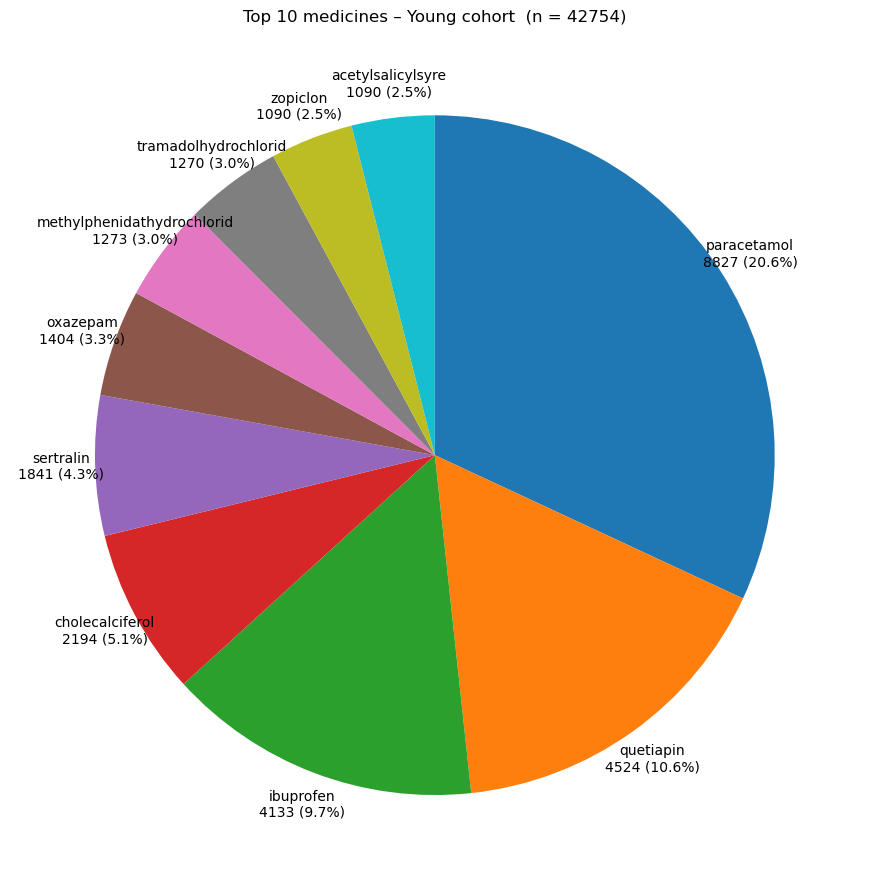

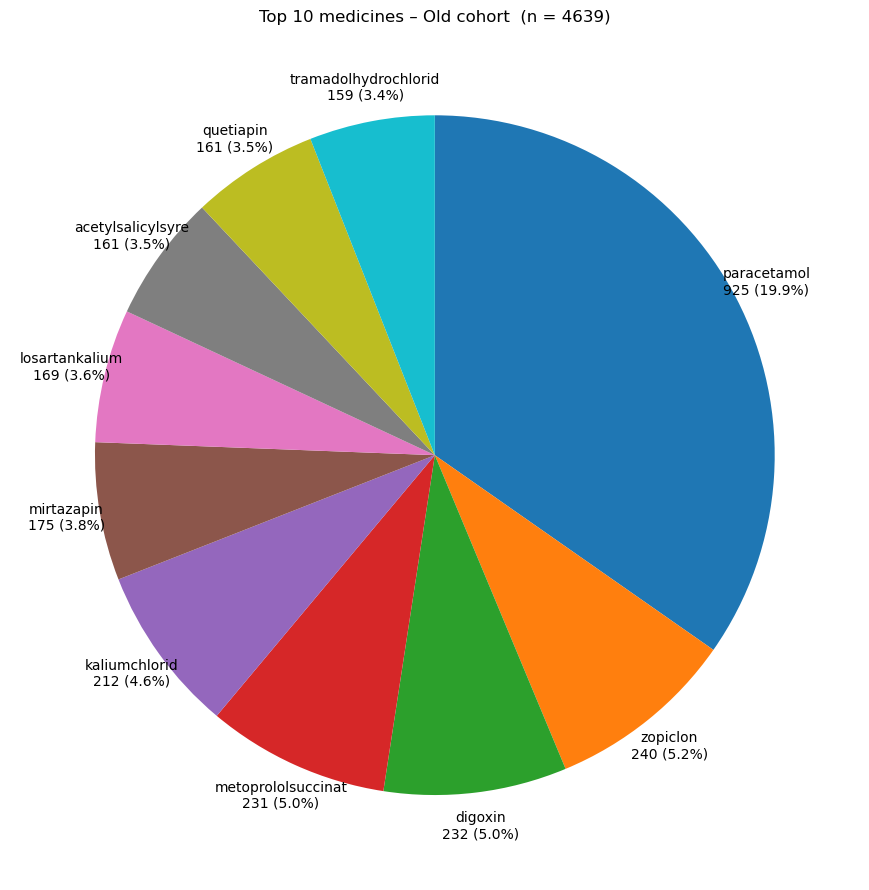

In [61]:
# ---------------------------------------------------------------------------
# 1.  How many rows contain each medicine?  (one hit per row & medicine)
# ---------------------------------------------------------------------------
def row_presence_counter(df: pd.DataFrame) -> Counter:
    """
    Counter {canonical_medicine → rows-where-it-appears}
    A medicine is counted once per row even if it shows up in several columns.
    """
    counter = Counter()

    for _, row in df[name_cols].iterrows():
        present = set()                                  # medicines seen in this row
        for col in name_cols:
            val = row[col]
            if pd.isnull(val):
                continue
            for token in split_words(str(val)):
                if token in medicines:
                    token = synonym_to_canonical.get(token, token)  # canonical name
                    present.add(token)
        counter.update(present)                           # +1 for every medicine seen
    return counter


# ---------------------------------------------------------------------------
# 2.  Prepare the “top-10” lists: medicine, count, percent-of-rows
# ---------------------------------------------------------------------------
def prepare_top_ten(counter: Counter, total_rows: int):
    top10      = counter.most_common(10)                 # [(med, cnt), …]
    medicines  = [m for m, _ in top10]
    counts     = [c for _, c in top10]
    percents   = [c / total_rows * 100 for c in counts]  # % of *all* rows
    return medicines, counts, percents


# ---------------------------------------------------------------------------
# 3.  Draw one pie chart – shows name, count & percentage on two lines
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

def plot_top10_pie(medicines, counts, percents, cohort, total_rows):
    # assemble multi-line labels:  “Drug\n123 (15.7 %)”
    labels = [
        f"{med}\n{cnt} ({pct:.1f}%)"
        for med, cnt, pct in zip(medicines, counts, percents)
    ]

    plt.figure(figsize=(9, 9))
    plt.pie(
        counts,                       # raw counts drive the wedge sizes
        labels=labels,
        startangle=90,
        counterclock=False,
        textprops={"ha": "center"},   # centre both label lines
    )
    plt.title(f"Top 10 medicines – {cohort} cohort  (n = {total_rows})")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 4.  Run for the two filtered data sets
# ---------------------------------------------------------------------------
for df, cohort in [(young_filtered, "Young"), (old_filtered, "Old")]:
    total_rows         = len(df)
    row_counter        = row_presence_counter(df)
    meds, counts, pcts = prepare_top_ten(row_counter, total_rows)
    plot_top10_pie(meds, counts, pcts, cohort, total_rows)

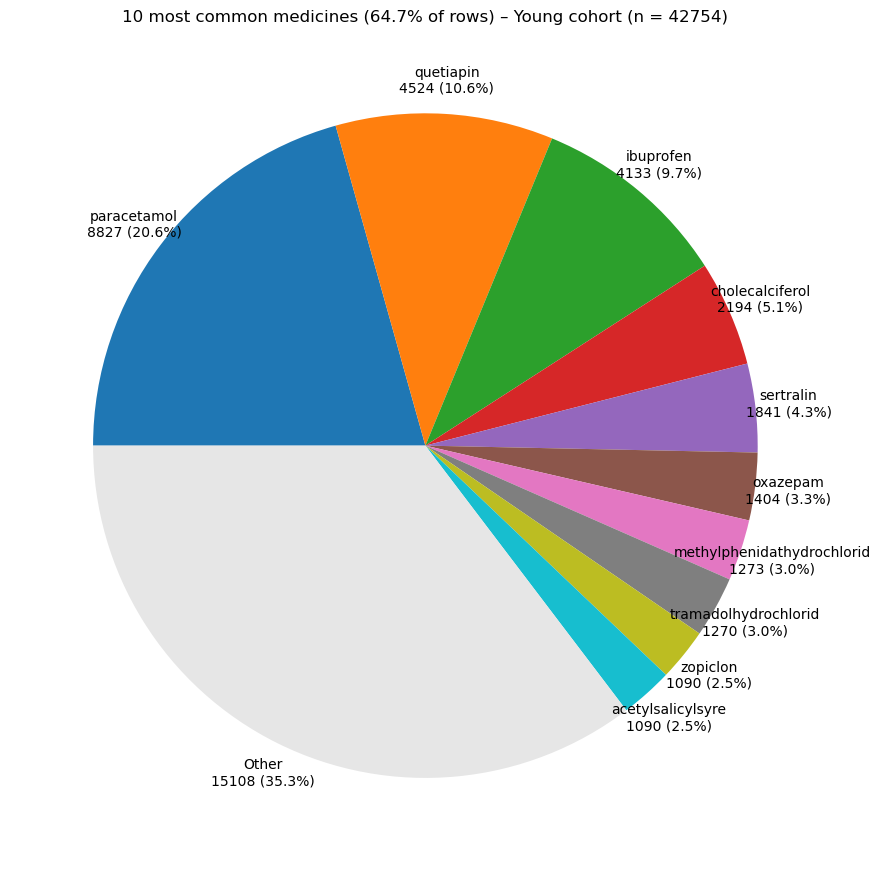

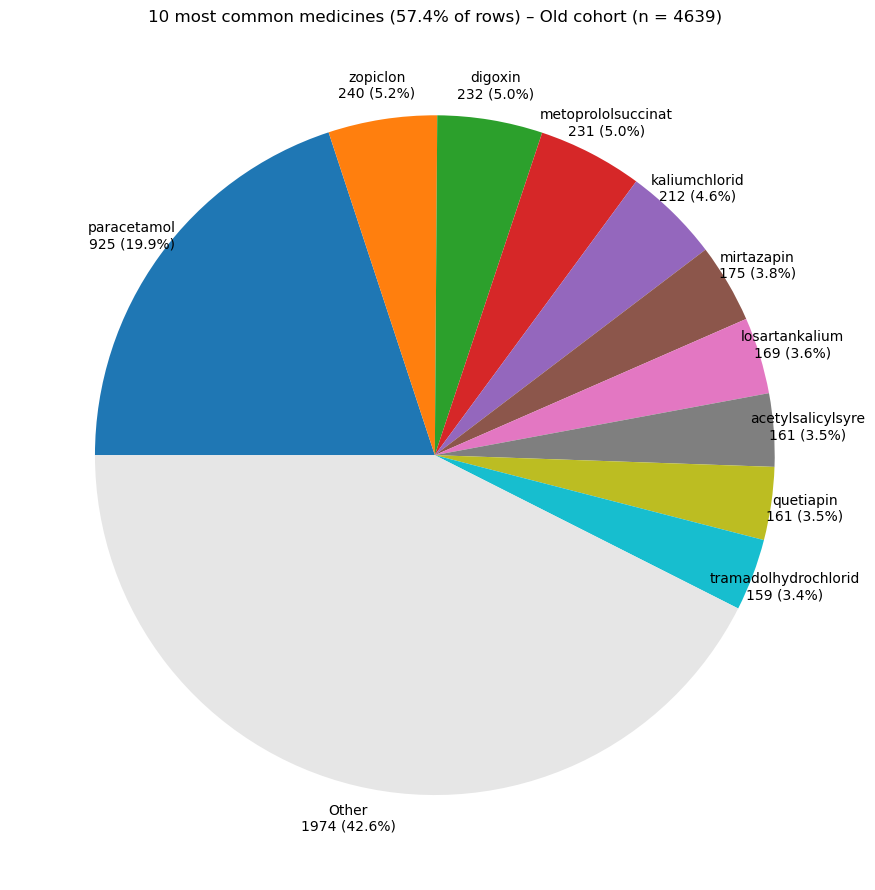

In [62]:
# ---------------------------------------------------------------------------
# 1.  Rows-per-medicine (unchanged)
# ---------------------------------------------------------------------------
def row_presence_counter(df: pd.DataFrame) -> Counter:
    counter = Counter()
    for _, row in df[name_cols].iterrows():
        present = set()
        for col in name_cols:
            v = row[col]
            if pd.isnull(v):
                continue
            for tok in split_words(str(v)):
                if tok in medicines:
                    tok = synonym_to_canonical.get(tok, tok)
                    present.add(tok)
        counter.update(present)
    return counter


# ---------------------------------------------------------------------------
# 2.  Build data for a 10-medicines-plus-other pie
# ---------------------------------------------------------------------------
def prepare_pie_data(counter: Counter, total_rows: int, top_n: int = 10):
    top = counter.most_common(top_n)           # [(drug, cnt), …]

    labels  = [drug for drug, _ in top]
    counts  = [cnt  for _, cnt  in top]

    other_cnt = total_rows - sum(counts)
    if other_cnt > 0:
        labels.append("Other")
        counts.append(other_cnt)

    percents = [c / total_rows * 100 for c in counts]

    coverage_pct = sum(counts[:-1]) / total_rows * 100 if other_cnt > 0 else 100.0
    return labels, counts, percents, coverage_pct


# ---------------------------------------------------------------------------
# 3.  Plot – light-grey “Other”, rotated 90° CCW
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import itertools

def plot_pie(labels, counts, percents, coverage_pct, cohort, total_rows):
    # two-line labels:  Drug\n123 (15.7%)
    full_labels = [
        f"{lab}\n{cnt} ({pct:.1f}%)"
        for lab, cnt, pct in zip(labels, counts, percents)
    ]

    # colour list with very light grey for “Other”
    base_cycle  = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    colours = [
        "#E6E6E6" if lab.lower() == "other" else next(base_cycle)
        for lab in labels
    ]

    plt.figure(figsize=(9, 9))
    plt.pie(
        counts,
        labels=full_labels,
        colors=colours,
        startangle=180,          # 90° CCW compared with startangle=90
        counterclock=False,
        textprops={"ha": "center"},
    )

    plt.title(
        f"10 most common medicines ({coverage_pct:.1f}% of rows) – "
        f"{cohort} cohort (n = {total_rows})"
    )
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 4.  Produce charts for the two cohorts
# ---------------------------------------------------------------------------
for df, cohort in [(young_filtered, "Young"), (old_filtered, "Old")]:
    total_rows = len(df)
    counter    = row_presence_counter(df)
    labs, cnts, pcts, cover_pct = prepare_pie_data(counter, total_rows)
    plot_pie(labs, cnts, pcts, cover_pct, cohort, total_rows)

ToDo:
- combine all the 'årsag' 
- looking at the column "substans type" next. we will look at all the substance type values, and see if we can eliminate some.

```text
MED                             40091
ZZMED                           22712
RUS                              4507
DIVERSE                          3269
KEMI                             1544
SPECIALDONOTDELETE               1286
MED | ZZMED                       715
BIO                               523
```